# 📊 01 - 数据获取与探索

本 Notebook 演示：
1. 配置系统加载
2. 下载股票历史数据
3. 探索数据结构和可视化

## 1. 加载配置

In [3]:
import sys
sys.path.insert(0, '..')

from config.settings import get_settings

settings = get_settings()
print(f'✅ 配置已加载')
print(f'   手数: {settings.trading.lot_size} 股')
print(f'   T+1: {settings.trading.t_plus_one}')
print(f'   佣金: {settings.commission.commission.rate*100:.3f}% (最低{settings.commission.commission.min_amount}元)')
print(f'   印花税: {settings.commission.stamp_duty.rate*100:.3f}% (卖出收)')
print(f'   板块: {list(settings.trading.boards.keys())}')

✅ 配置已加载
   手数: 100 股
   T+1: True
   佣金: 0.025% (最低5.0元)
   印花税: 0.050% (卖出收)
   板块: ['sh_main', 'sz_main', 'chinext', 'star_market', 'bse']


## 2. 获取股票列表

In [4]:
from src.data.aggregator import DataAggregator
from datetime import date

agg = DataAggregator()

# 获取全部A股列表
stocks = agg.get_stock_list()
print(f'📋 A股总数: {len(stocks)} 只')
print(f'\n前10只:')
for s in stocks[:10]:
    print(f'  {s.symbol}  {s.name}')

📋 A股总数: 5524 只

前10只:
  000001.SZ  平安银行
  000002.SZ  万  科Ａ
  000004.SZ  *ST国华
  000006.SZ  深振业Ａ
  000007.SZ  全新好
  000008.SZ  神州高铁
  000009.SZ  中国宝安
  000010.SZ  *ST美丽
  000011.SZ  深物业A
  000012.SZ  南  玻Ａ


## 3. 下载历史日线数据

In [5]:
# 选择你要分析的股票
my_stocks = [
    '600519.SH',  # 贵州茅台
    '000001.SZ',  # 平安银行
    '300750.SZ',  # 宁德时代
    '000858.SZ',  # 五粮液
    '601318.SH',  # 中国平安
]

start = date(2025, 1, 1)
end = date.today()

print(f'📥 下载 {len(my_stocks)} 只股票从 {start} 到 {end} ...')

bars = agg.get_bars_batch(my_stocks, start, end)
print(f'✅ 获取 {len(bars)} 条日线数据')
print(f'   股票数: {bars.index.get_level_values(1).nunique()}')
print(f'   交易日: {bars.index.get_level_values(0).nunique()}')

📥 下载 5 只股票从 2025-01-01 到 2026-06-04 ...
✅ 获取 1705 条日线数据
   股票数: 5
   交易日: 341


In [6]:
# 查看数据前几行
bars.head(10)

,,open,high,low,close,volume,amount,adjusted_close
date,symbol,,,,,,,
2025-01-02,600519.SH,1524.00,1524.49,1480.00,1488.00,5002870,0.0,1488.00
2025-01-03,600519.SH,1494.50,1494.99,1467.01,1475.00,3262836,0.0,1475.00
2025-01-06,600519.SH,1453.00,1462.66,1432.80,1440.00,4425512,0.0,1440.00
2025-01-07,600519.SH,1444.66,1451.89,1439.00,1440.20,2422118,0.0,1440.20
2025-01-08,600519.SH,1440.00,1451.82,1426.66,1442.50,3525821,0.0,1442.50
2025-01-09,600519.SH,1448.99,1464.58,1432.98,1444.00,2970565,0.0,1444.00
2025-01-10,600519.SH,1447.10,1451.95,1436.00,1436.00,2187195,0.0,1436.00
2025-01-13,600519.SH,1425.00,1444.44,1422.01,1443.98,2108251,0.0,1443.98
2025-01-14,600519.SH,1444.95,1478.68,1442.00,1472.50,3095657,0.0,1472.50


## 4. 可视化：价格走势

/var/folders/f_/2pdk_rtd78vf3ts285qjf2sc0000gn/T/ipykernel_33340/2537066926.py:18: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f_/2pdk_rtd78vf3ts285qjf2sc0000gn/T/ipykernel_33340/2537066926.py:18: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f_/2pdk_rtd78vf3ts285qjf2sc0000gn/T/ipykernel_33340/2537066926.py:18: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f_/2pdk_rtd78vf3ts285qjf2sc0000gn/T/ipykernel_33340/2537066926.py:18: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f_/2pdk_rtd78vf3ts285qjf2sc0000gn/T/ipykernel_33340/2537066926.py:18: UserWarning: Glyph 31080 (\N{CJK UNIFIED IDEOGRAPH-7968}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f_/2pdk_

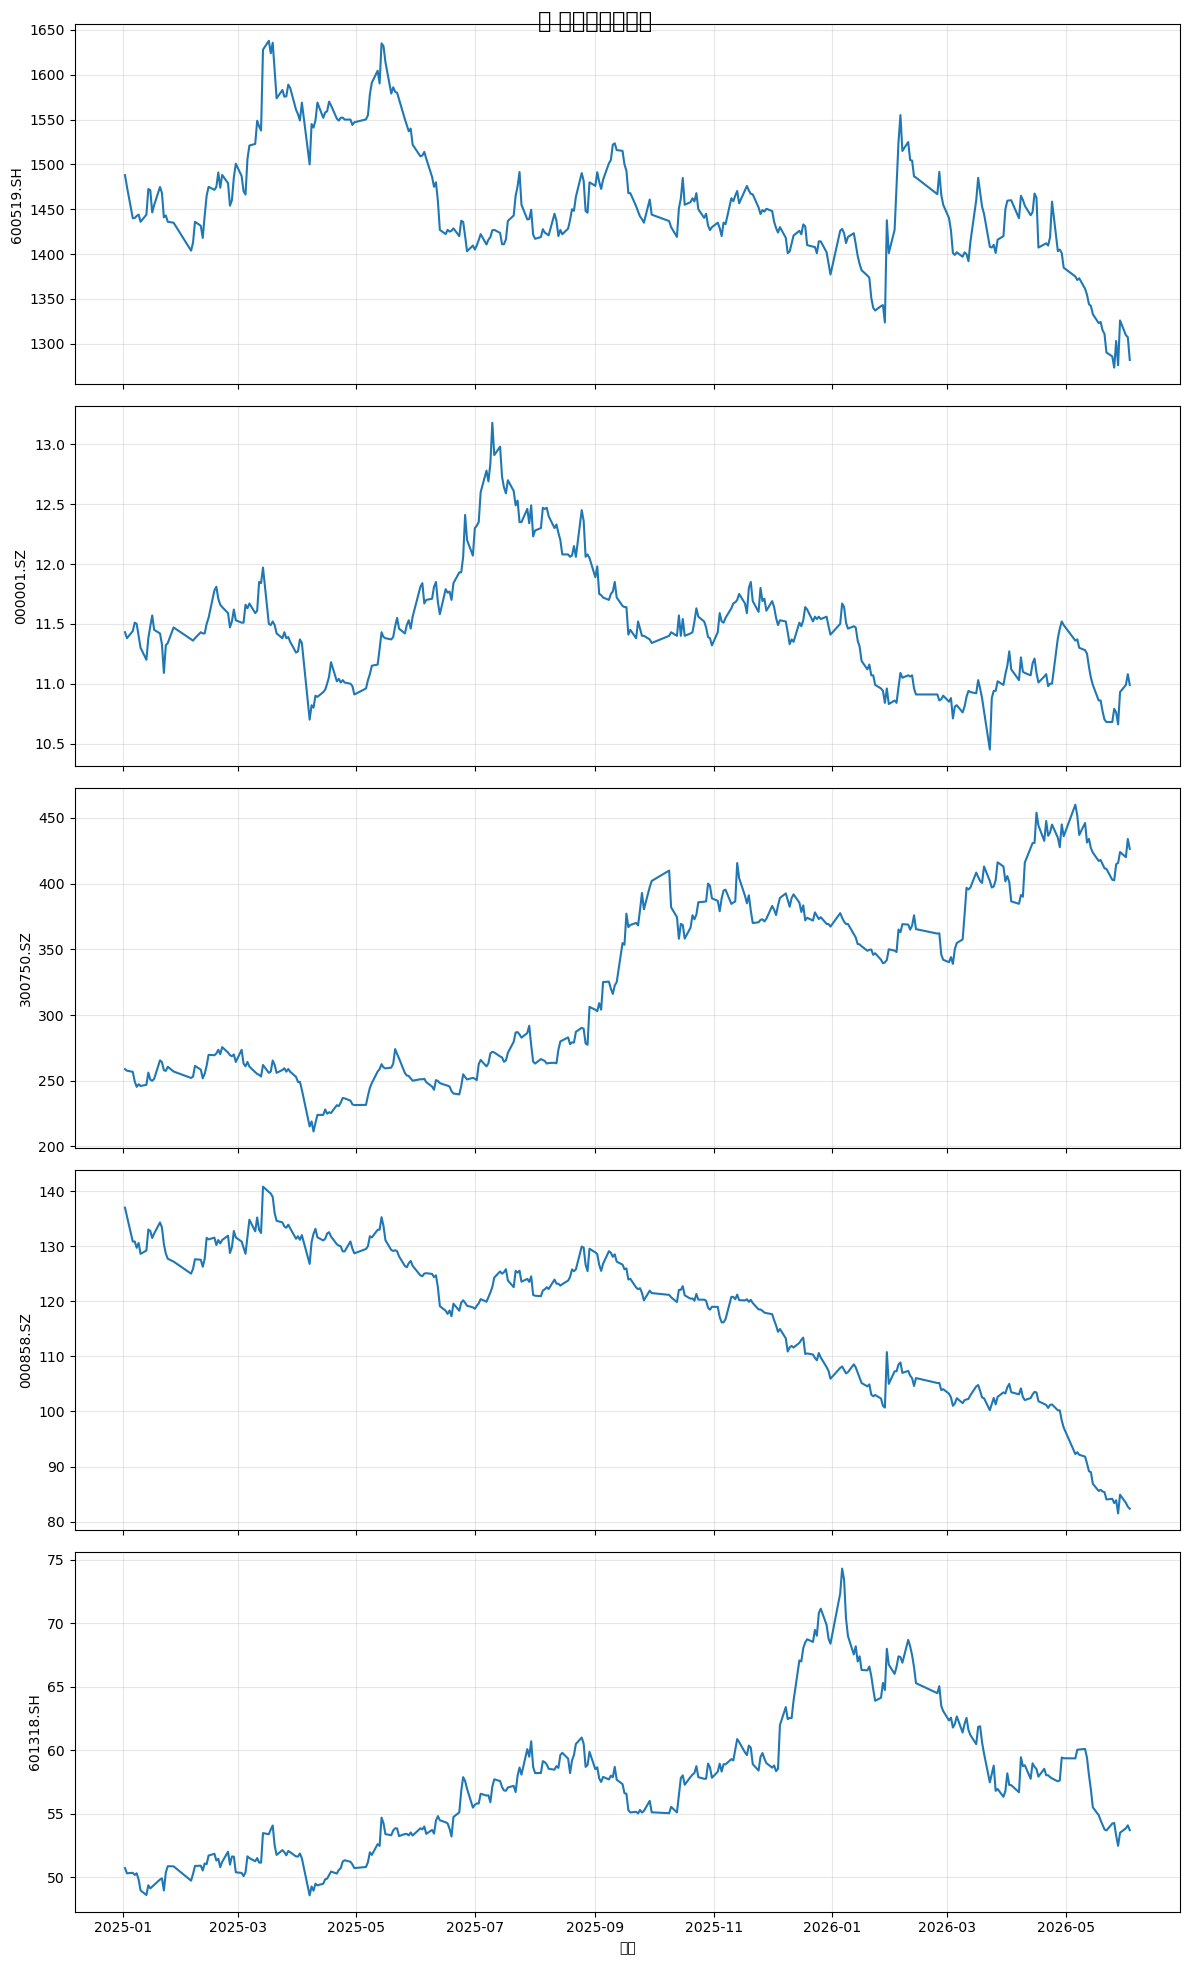

In [7]:
import matplotlib.pyplot as plt

# 各股票收盘价
close = bars['close'].unstack(level=1)

fig, axes = plt.subplots(len(my_stocks), 1, figsize=(12, 4*len(my_stocks)), sharex=True)
if len(my_stocks) == 1:
    axes = [axes]

for i, sym in enumerate(my_stocks):
    if sym in close.columns:
        axes[i].plot(close.index, close[sym], linewidth=1.5)
        axes[i].set_ylabel(sym, fontsize=10)
        axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('日期')
fig.suptitle('📈 股票收盘价走势', fontsize=16)
plt.tight_layout()
plt.show()

## 5. 可视化：收益率分布

/var/folders/f_/2pdk_rtd78vf3ts285qjf2sc0000gn/T/ipykernel_33340/2369170583.py:16: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f_/2pdk_rtd78vf3ts285qjf2sc0000gn/T/ipykernel_33340/2369170583.py:16: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f_/2pdk_rtd78vf3ts285qjf2sc0000gn/T/ipykernel_33340/2369170583.py:16: UserWarning: Glyph 30410 (\N{CJK UNIFIED IDEOGRAPH-76CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f_/2pdk_rtd78vf3ts285qjf2sc0000gn/T/ipykernel_33340/2369170583.py:16: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f_/2pdk_rtd78vf3ts285qjf2sc0000gn/T/ipykernel_33340/2369170583.py:16: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f_/2pdk

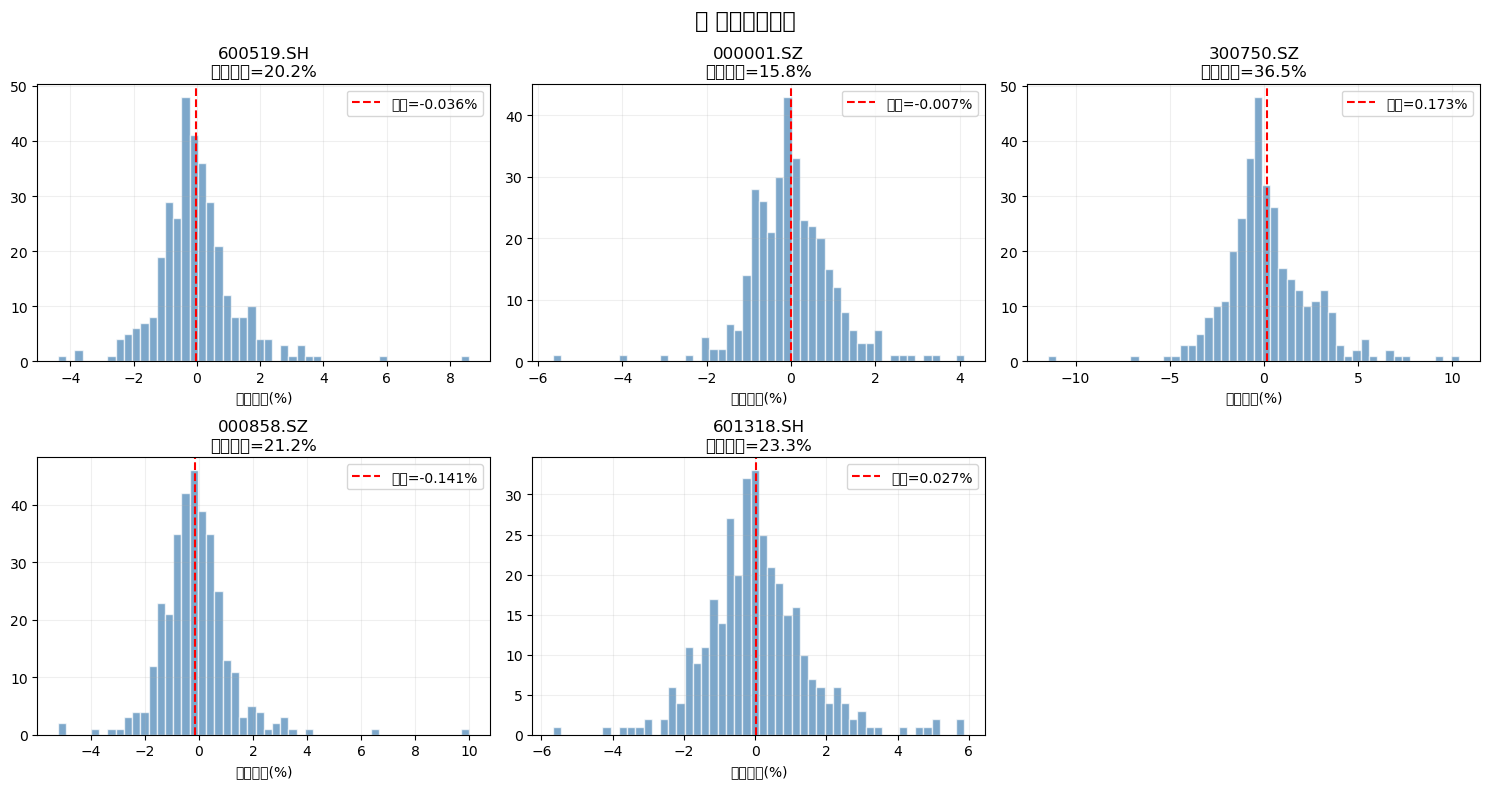

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, sym in enumerate(my_stocks):
    if sym in close.columns:
        daily_ret = close[sym].pct_change().dropna() * 100
        axes[i].hist(daily_ret, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
        axes[i].axvline(daily_ret.mean(), color='red', linestyle='--', label=f'均值={daily_ret.mean():.3f}%')
        axes[i].set_title(f'{sym}\n年化波动={daily_ret.std()*252**0.5:.1f}%')
        axes[i].set_xlabel('日收益率(%)')
        axes[i].legend()
        axes[i].grid(True, alpha=0.2)

axes[-1].axis('off')
fig.suptitle('📊 日收益率分布', fontsize=16)
plt.tight_layout()
plt.show()

## 6. 交易日历检查

In [10]:
from src.core.calendar import TradingCalendar

cal = TradingCalendar()

# 检查特定日期
test_dates = ['2025-06-03', '2025-06-07', '2025-10-01', '2026-01-01']
for d in test_dates:
    is_td = cal.is_trading_day(d)
    print(f'  {d}: {"交易日✅" if is_td else "非交易日❌"}')

# 2025年6月所有交易日
days = cal.get_trading_days('2025-06-01', '2025-06-30')
print(f'\n📅 2025年6月: {len(days)} 个交易日')
print(f'  {" ".join(d.strftime("%d") for d in days)}')

  2025-06-03: 交易日✅
  2025-06-07: 非交易日❌
  2025-10-01: 非交易日❌
  2026-01-01: 非交易日❌

📅 2025年6月: 20 个交易日
  03 04 05 06 09 10 11 12 13 16 17 18 19 20 23 24 25 26 27 30
